In [1]:
from torch_geometric.datasets import OGB_MAG

dataset = OGB_MAG(root="/tmp/ogb_mag", preprocess="metapath2vec")

/Users/tungvuduc/opt/anaconda3/envs/dlbio_arm64/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
graph = dataset[0]

print("Display the node and edge attributes:")

node_type = graph.metadata()[0]
edge_type = graph.metadata()[1]
print("Node types:")
print(node_type)
print()

print("Edge type:")
print(edge_type)
print()

print(graph["paper"])
print(graph["paper"].x)
print()

print('graph["paper", "cites", "paper"]:')
print(graph["paper", "cites", "paper"])
print()

print("Is the data undirected:", graph.is_undirected())
print("Does it have isolated nodes:", graph.has_isolated_nodes())
print("Does the graph have self loops:", graph.has_isolated_nodes())

Display the node and edge attributes:
Node types:
['paper', 'author', 'institution', 'field_of_study']

Edge type:
[('author', 'affiliated_with', 'institution'), ('author', 'writes', 'paper'), ('paper', 'cites', 'paper'), ('paper', 'has_topic', 'field_of_study')]

{'x': tensor([[-0.0954,  0.0408, -0.2109,  ...,  0.0616, -0.0277, -0.1338],
        [-0.1510, -0.1073, -0.2220,  ...,  0.3458, -0.0277, -0.2185],
        [-0.1148, -0.1760, -0.2606,  ...,  0.1731, -0.1564, -0.2780],
        ...,
        [ 0.0228, -0.0865,  0.0981,  ..., -0.0547, -0.2077, -0.2305],
        [-0.2891, -0.2029, -0.1525,  ...,  0.1042,  0.2041, -0.3528],
        [-0.0890, -0.0348, -0.2642,  ...,  0.2601, -0.0875, -0.5171]]), 'year': tensor([2015, 2012, 2012,  ..., 2016, 2017, 2014]), 'y': tensor([246, 131, 189,  ..., 266, 289,   1]), 'train_mask': tensor([True, True, True,  ..., True, True, True]), 'val_mask': tensor([False, False, False,  ..., False, False, False]), 'test_mask': tensor([False, False, False,  ...,

In [3]:
# simple transformations
import torch_geometric.transforms as T

graph = T.ToUndirected()(graph)
# graph = T.AddSelfLoops()(graph)
graph = T.NormalizeFeatures()(graph)

In [4]:
from torch_geometric.nn import SAGEConv, GATConv, to_hetero, Linear
import torch.nn as nn
import torch
import torch.nn.functional as F

class SageGCN(nn.Module):
    def __init__(self, hidden_channel: int, num_classes: int, p: float, ):
        super().__init__()

        self.conv1 = SAGEConv((-1, -1), hidden_channel, aggr="sum")
        self.conv2 = SAGEConv(hidden_channel, hidden_channel, aggr="sum")
        self.dropout = nn.Dropout(p)
        self.relu = nn.ReLU()
        self.lin1 = nn.Linear(hidden_channel, num_classes)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):
        x = self.relu(self.conv1(x, edge_index))
        x = self.dropout(x)

        x = self.relu(self.conv2(x, edge_index))
        x = self.dropout(x)

        x = self.lin1(x)
        return x
    
# sage_model = SageGCN(hidden_channel=32, num_classes=len(torch.unique(graph["paper"].y)), p=0.5)
# sage_model = to_hetero(sage_model, graph.metadata(), aggr="sum")
# out = sage_model(graph.x_dict, graph.edge_index_dict)

In [5]:
class GatGCN(nn.Module):
    def __init__(self, hidden_channel: int, heads: int, dropout: float, num_classes: int):
        super().__init__()

        self.conv1 = GATConv((-1, -1), out_channels=hidden_channel, heads=heads, dropout=dropout, add_self_loops=False, concat=False)
        self.conv2 = GATConv((-1, -1), out_channels=hidden_channel, heads=heads, dropout=dropout, add_self_loops=False, concat=False)

        self.lin1 = Linear(-1, hidden_channel)
        self.lin2 = Linear(-1, hidden_channel)

        self.classifier_head = Linear(hidden_channel, num_classes)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):
        x = (self.conv1(x, edge_index) + self.lin1(x)).relu()
        x = (self.conv2(x, edge_index) + self.lin2(x)).relu()
        x = self.classifier_head(x)

        return x
# gat_model = GatGCN(hidden_channel=32, heads=2, dropout=0.5, num_classes=len(torch.unique(graph["paper"].y)))
# gat_model = to_hetero(gat_model, graph.metadata(), aggr="sum")

# output = gat_model(graph.x_dict, graph.edge_index_dict)

In [ ]:
from torch_geometric.loader import NeighborLoader
from torch_geometric.data import HeteroData
from tqdm import tqdm


train_mask = graph["paper"].train_mask
train_loader = NeighborLoader(
    graph,
    num_neighbors=[10, 10],  # neighbors per hop
    input_nodes=("paper", train_mask),
    batch_size=2048,
    num_workers=8,
    persistent_workers=True,
)

def train(model:SageGCN, optimizer: torch.optim, data: HeteroData, criterion: nn.NLLLoss):
    model.train()
    optimizer.zero_grad()
    batch_size = data["paper"].batch_size
    out = model(data.x_dict, data.edge_index_dict)["paper"][:batch_size]
    log = F.log_softmax(out, dim=-1)
    loss = criterion(log, data["paper"].y[:batch_size])
    loss.backward()
    optimizer.step()
    return out.detach(), loss.detach().item()

@torch.no_grad()
def val(model: SageGCN, data: HeteroData, criterion: nn.NLLLoss, mask:torch.Tensor):
    model.eval()
    out = model(data.x_dict, data.edge_index_dict)["paper"]
    log = F.log_softmax(out, dim=-1)
    loss = criterion(log[mask], data["paper"].y[mask])
    return out.detach(), loss.item()

def acc(out: torch.Tensor, y: torch.Tensor):
    y_pred = out.argmax(dim=1)
    return (y_pred == y).float().mean().item()

def train_val(epochs: int, train_loader: NeighborLoader, model: GatGCN, optimizer:torch.optim, criterion: nn.NLLLoss, graph: HeteroData, device: str):
    train_loss = []
    train_acc = []

    val_loss = []
    val_acc = []
    graph = graph.to(device)
    model = model.to(device)
    for _ in tqdm(range(epochs)):
        t_loss = 0
        t_acc = 0
        total_sample = 0
        for train_batch in train_loader:
            train_batch = train_batch.to(device)
            batch_size = train_batch["paper"].batch_size

            out, loss = train(model, optimizer, train_batch, criterion)

            t_loss += (loss * batch_size)
            t_acc += (acc(out, train_batch["paper"].y[:batch_size]) * batch_size)
            total_sample += train_batch["paper"].batch_size

        t_loss /= total_sample
        t_acc /= total_sample
        
        train_loss.append(t_loss)
        train_acc.append(t_acc)

        out, v_loss = val(model, graph, criterion, graph["paper"]["val_mask"])

        val_loss.append(v_loss)
        val_mask = graph["paper"].val_mask
        val_acc.append(acc(out[val_mask], graph["paper"].y[val_mask]))

    return {
        "model": model,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc
    }


In [27]:
sage_model = SageGCN(hidden_channel=16, num_classes=len(torch.unique(graph["paper"].y)), p=0.5)
sage_model = to_hetero(sage_model, graph.metadata(), aggr="sum")

optimizer = torch.optim.Adam(sage_model.parameters(), lr=0.001)
criterion = nn.NLLLoss()

print("Testing Sage GCN")
for test_batch in train_loader:
    train_out, train_loss = train(sage_model, optimizer, test_batch, criterion)
    val_out, val_loss = val(sage_model, test_batch, criterion, test_batch["paper"]["val_mask"])
    batch_size = test_batch["paper"].batch_size
    train_acc = acc(train_out, test_batch["paper"].y[:batch_size])
    print("train loss:", train_loss)
    print("val loss:", val_loss)
    print("train acc:", train_acc)
    break
print("==="*20)

gat_model = GatGCN(hidden_channel=16, heads=2, dropout=0.5, num_classes=len(torch.unique(graph["paper"].y)))
gat_model = to_hetero(gat_model, graph.metadata(), aggr="sum")
optimizer = torch.optim.Adam(sage_model.parameters(), lr=0.001)
criterion = nn.NLLLoss()

print("Testing GAT GCN")
for test_batch in train_loader:
    train_out, train_loss = train(gat_model, optimizer, test_batch, criterion)
    val_out, val_loss = val(gat_model, test_batch, criterion, test_batch["paper"]["val_mask"])
    batch_size = test_batch["paper"].batch_size
    train_acc = acc(train_out, test_batch["paper"].y[:batch_size])
    print("train loss:", train_loss)
    print("val loss:", val_loss)
    print("train acc:", train_acc)
    break

Testing Sage GCN
train loss: 5.861079692840576
val loss: 5.845644950866699
train acc: 0.001953125
Testing GAT GCN
train loss: 5.901171684265137
val loss: 5.892153739929199
train acc: 0.0009765625


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
sage_model = SageGCN(hidden_channel=16, num_classes=len(torch.unique(graph["paper"].y)), p=0.5)
sage_model = to_hetero(sage_model, graph.metadata(), aggr="sum")
optimizer = torch.optim.Adam(sage_model.parameters(), lr=0.01)
criterion = nn.NLLLoss()
sage_result = train_val(5, train_loader, sage_model, optimizer, criterion, graph, device)

gat_model = GatGCN(hidden_channel=16, heads=2, dropout=0.5, num_classes=len(torch.unique(graph["paper"].y)))
gat_model = to_hetero(gat_model, graph.metadata(), aggr="sum")
optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.01)
criterion = nn.NLLLoss()
gat_result = train_val(5, train_loader, gat_model, optimizer, criterion, graph, device)         

  0%|          | 0/5 [00:04<?, ?it/s]
libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipe
libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipe


KeyboardInterrupt: 

libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipe


In [15]:
sage_result["val_loss"]

[285.7793273925781,
 266.8014221191406,
 325.95318603515625,
 276.9995422363281,
 317.6795654296875]

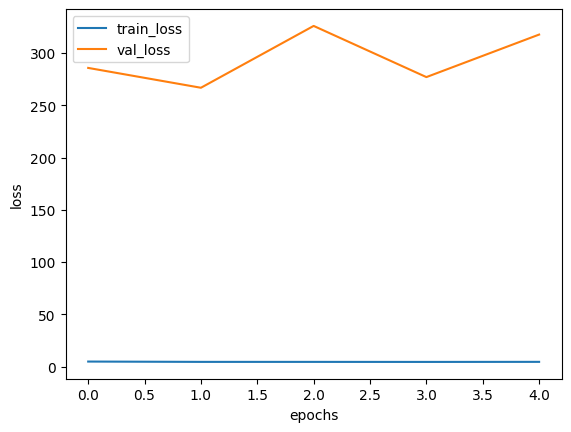

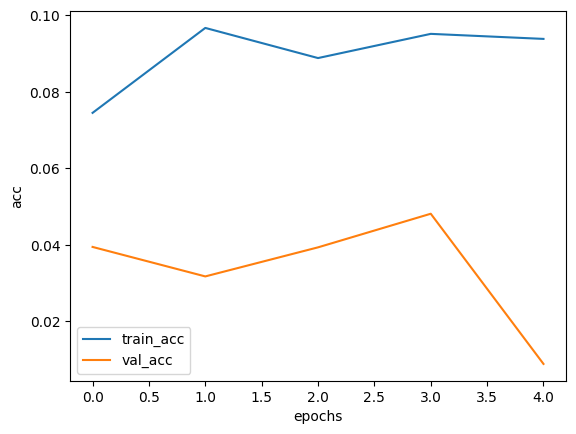

NameError: name 'gat_result' is not defined

In [9]:
import matplotlib.pyplot as plt

plt.plot(sage_result["train_loss"], label="train_loss")
plt.plot(sage_result["val_loss"], label="val_loss")
plt.legend()
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

plt.plot(sage_result["train_acc"], label="train_acc")
plt.plot(sage_result["val_acc"], label="val_acc")
plt.xlabel("epochs")
plt.ylabel("acc")
plt.legend()
plt.show()

plt.plot(gat_result["train_loss"], label="train_loss")
plt.plot(gat_result["val_loss"], label="val_loss")
plt.legend()
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

plt.plot(gat_result["train_acc"], label="train_acc")
plt.plot(gat_result["val_acc"], label="val_acc")
plt.xlabel("epochs")
plt.ylabel("acc")
plt.legend()

plt.show()

In [ ]:
# heterogenous conv wrapper for different edge types
from torch_geometric.nn import HeteroConv, GCNConv

class HetGNN(nn.Module):
    def __init__(self, num_layers: int, hidden_channel: int, num_classes: int):
        super().__init__()
        self.convs = nn.ModuleList()
        for _ in num_layers:
            conv = HeteroConv(
                {
                ("author", "affiliated_with", "institution"): SAGEConv(-1, hidden_channel, aggr="sum"),
                ("author", "writes", "paper"): SAGEConv(-1, hidden_channel, aggr="sum"),
                ("paper", "cites", "paper"): GCNConv(-1, hidden_channel),
                ("paper", "has_topic", "field_of_study") : GCNConv(-1, hidden_channel)
                }
            )
            self.convs.append(conv)

        self.linear = Linear(-1, num_classes)
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):
        for conv in convs:
            out = conv(x, edge_index)
        convs = {key: value.relu() for key, value in out.items()}
        out = self.linear(convs["paper"])
        return convs

In [ ]:
[('author', 'affiliated_with', 'institution'), ('author', 'writes', 'paper'), ('paper', 'cites', 'paper'), ('paper', 'has_topic', 'field_of_study')]
